# Efficient Sequence-to-Sequence Question Generation from Textual Contexts Using a Fine-Tuned Transformer Model with Gradient Accumulation and Multi-Criteria Quality Evaluation
This notebook fine-tunes a T5-small model on the SQuAD dataset for sequence-to-sequence question generation using standard supervised learning.
Note: It does NOT use reinforcement learning or knowledge-grounded augmentation as previously claimed.

In [ ]:
# Cell 1: Install Dependencies
print("Installing required packages...")
!pip install transformers datasets torch torchtext nltk rouge-score
!pip install sentencepiece protobuf accelerate
!pip install evaluate
!pip install gradio
!pip install requests
!pip install flask-ngrok
!pip install pyngrok
!pip install wandb

print("All packages installed successfully!")

Installing required packages...
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 21.0 MB/s eta 0:00:00
  Created wheel for rouge-score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=fbca38ff9ae58a9da0da01e07793fb46bfec4a76b4d3b81df2db3fe936d28c57
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
Successfully built rouge-score
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.0 MB/s eta 0:00:00
All packages installed successfully!


In [ ]:
# Cell 2: Import Libraries
import torch
import torch.nn as nn
from transformers import T5Tokenizer, T5ForConditionalGeneration
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup
from datasets import load_dataset
import pandas as pd
import numpy as np
from tqdm.auto import tqdm
import nltk
from nltk.translate.bleu_score import sentence_bleu, corpus_bleu, SmoothingFunction
from nltk.tokenize import word_tokenize
import evaluate
from rouge_score import rouge_scorer
import random
import json
from torch.utils.data import Dataset, DataLoader
import warnings
import os
import gradio as gr
import requests
import tempfile
import pickle
import time
from flask import Flask, request, jsonify
from flask_ngrok import run_with_ngrok
from pyngrok import ngrok
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score

import wandb


try:
    from google.colab import drive
    drive.mount('/content/drive')
    print("Google Drive successfully mounted!")
except Exception as e:
    print("Not running in Google Colab or Drive mount failed. Using local paths.")


warnings.filterwarnings('ignore')

# Download NLTK data
nltk.download('punkt')

print("All libraries imported successfully!")

Mounted at /content/drive
✅ Google Drive successfully mounted!


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


All libraries imported successfully!


In [ ]:
# Cell 3: Configuration with Permanent Paths
class Config:
    # Model
    MODEL_NAME = "t5-small"
    MAX_LENGTH = 384
    TARGET_MAX_LENGTH = 64

    # Training
    BATCH_SIZE = 8
    GRADIENT_ACCUMULATION_STEPS = 4
    EPOCHS = 8
    LEARNING_RATE = 3e-4
    WARMUP_STEPS = 500
    MAX_TRAIN_SAMPLES = 20000
    MAX_VAL_SAMPLES = 2000

    # Generation
    NUM_BEAMS = 4
    MAX_GENERATION_LENGTH = 64
    REPETITION_PENALTY = 2.5

    # PATHS - Using Drive for permanent storage
    MODEL_SAVE_PATH = "/content/drive/MyDrive/Question_Generation_Training_V2/question_generation_model"
    ANALYTICAL_MODEL_PATH = "/content/drive/MyDrive/Question_Generation_Training_V2/analytical_model"
    RESULTS_PATH = "/content/drive/MyDrive/Question_Generation_Training_V2/training_results"

config = Config()
# Create directories with proper error handling
def create_directories():
    """Create all necessary directories"""
    directories = [
        config.MODEL_SAVE_PATH,
        config.ANALYTICAL_MODEL_PATH,
        config.RESULTS_PATH
    ]

    for directory in directories:
        try:
            os.makedirs(directory, exist_ok=True)
            print(f" Created directory: {directory}")
        except Exception as e:
            print(f"Error creating {directory}: {e}")

create_directories()

print("Directory issues fixed!")

✅ Created directory: /content/drive/MyDrive/Question_Generation_Training_V2/question_generation_model
✅ Created directory: /content/drive/MyDrive/Question_Generation_Training_V2/analytical_model
✅ Created directory: /content/drive/MyDrive/Question_Generation_Training_V2/training_results
✅ Directory issues fixed!


In [ ]:
# Cell 4: Model Manager for Persistent Storage
class ModelManager:
    def __init__(self):
        self.base_model_loaded = False
        self.analytical_model_loaded = False
        self.base_model = None
        self.analytical_model = None

    def save_training_history(self, history, filename="training_history.pkl"):
        """Save training history for plots"""
        with open(os.path.join(config.RESULTS_PATH, filename), 'wb') as f:
            pickle.dump(history, f)

    def load_training_history(self, filename="training_history.pkl"):
        """Load training history"""
        try:
            with open(os.path.join(config.RESULTS_PATH, filename), 'rb') as f:
                return pickle.load(f)
        except:
            return None

    def model_exists(self, model_type="base"):
        """Check if model exists"""
        if model_type == "base":
            path = config.MODEL_SAVE_PATH
        else:
            path = config.ANALYTICAL_MODEL_PATH

        return os.path.exists(os.path.join(path, "pytorch_model.bin"))

    def save_model(self, model, tokenizer, model_type="base"):
        """Save model properly"""
        if model_type == "base":
            path = config.MODEL_SAVE_PATH
        else:
            path = config.ANALYTICAL_MODEL_PATH

        model.save_pretrained(path)
        tokenizer.save_pretrained(path)
        print(f"✅ {model_type.capitalize()} model saved to {path}")

    def load_model(self, model_type="base"):
        """Load model if exists"""
        if model_type == "base":
            path = config.MODEL_SAVE_PATH
        else:
            path = config.ANALYTICAL_MODEL_PATH

        if self.model_exists(model_type):
            print(f"✅ Loading existing {model_type} model...")
            tokenizer = T5Tokenizer.from_pretrained(path)
            model = T5ForConditionalGeneration.from_pretrained(path)

            if model_type == "base":
                self.base_model_loaded = True
                self.base_model = (model, tokenizer)
            else:
                self.analytical_model_loaded = True
                self.analytical_model = (model, tokenizer)

            return model, tokenizer
        else:
            print(f"No existing {model_type} model found.")
            return None, None

    def save_checkpoint(self, epoch, optimizer, scheduler, best_bleu, history, filename="checkpoint.pt"):
        """Save training checkpoint to resume later"""
        checkpoint_path = os.path.join(config.RESULTS_PATH, filename)
        torch.save({
            'epoch': epoch,
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'best_bleu': best_bleu,
            'history': history
        }, checkpoint_path)
        print(f"Checkpoint saved to {checkpoint_path}")

    def load_checkpoint(self, filename="checkpoint.pt"):
        """Load training checkpoint"""
        checkpoint_path = os.path.join(config.RESULTS_PATH, filename)
        if os.path.exists(checkpoint_path):
            print(f"✅ Loading checkpoint from {checkpoint_path}...")
            return torch.load(checkpoint_path)
        return None

model_manager = ModelManager()

In [ ]:
# Cell 5: Optimized Data Preparation with Caching
class QuestionGenerationDataset(Dataset):
    def __init__(self, tokenizer, data, max_length=384, target_max_length=64):
        self.tokenizer = tokenizer
        self.data = data
        self.max_length = max_length
        self.target_max_length = target_max_length

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]

        # Format for question generation
        input_text = f"generate question: {item['context']}"
        target_text = item['question']

        # Tokenize inputs
        inputs = self.tokenizer(
            input_text,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors="pt"
        )

        # Tokenize targets
        targets = self.tokenizer(
            target_text,
            max_length=self.target_max_length,
            padding='max_length',
            truncation=True,
            return_tensors="pt"
        )

        return {
            'input_ids': inputs['input_ids'].flatten(),
            'attention_mask': inputs['attention_mask'].flatten(),
            'labels': targets['input_ids'].flatten()
        }

def prepare_squad_data_optimized():
    """Optimized data loading with proper caching - Train/Val/Test Split"""
    cache_file = "/content/drive/MyDrive/Question_Generation_Training_V2/squad_data_full_v2.pkl"

    if os.path.exists(cache_file):
        print("Loading cached SQuAD data...")
        with open(cache_file, 'rb') as f:
            train_data, valid_data, test_data = pickle.load(f)
        return train_data, valid_data, test_data

    print("Loading SQuAD dataset...")
    dataset = load_dataset("squad")

    train_data = []
    valid_data = []
    test_data = []

    print("Processing training data...")
    for i, item in enumerate(tqdm(dataset['train'])):
        if i >= config.MAX_TRAIN_SAMPLES:
            break
        train_data.append({'context': item['context'], 'question': item['question']})

    print("Processing validation & test data...")
    for i, item in enumerate(tqdm(dataset['validation'])):
        if i < config.MAX_VAL_SAMPLES:
            valid_data.append({'context': item['context'], 'question': item['question']})
        elif i >= config.MAX_VAL_SAMPLES and i < config.MAX_VAL_SAMPLES + 500:
            test_data.append({'context': item['context'], 'question': item['question']})
        if i >= config.MAX_VAL_SAMPLES + 500:
            break

    with open(cache_file, 'wb') as f:
        pickle.dump((train_data, valid_data, test_data), f)

    print(f"✅ Training samples: {len(train_data)}")
    print(f"✅ Validation samples: {len(valid_data)}")
    print(f"✅ Testing samples: {len(test_data)}")
    return train_data, valid_data, test_data

In [ ]:
# Cell 6: Optimized Model Implementation with Gradient Accumulation
class T5QuestionGenerator:
    def __init__(self, model_name="t5-small"):
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        print(f"Using device: {self.device}")

        # Check if we can load existing model
        existing_model, existing_tokenizer = model_manager.load_model("base")
        if existing_model is not None:
            self.model = existing_model
            self.tokenizer = existing_tokenizer
            print("✅ Loaded existing base model!")
        else:
            self.tokenizer = T5Tokenizer.from_pretrained(model_name)
            self.model = T5ForConditionalGeneration.from_pretrained(model_name)
            print("✅ Initialized new base model!")

        self.model.to(self.device)
        self.training_history = []

    def train_optimized(self, train_loader, val_loader, epochs=3, learning_rate=3e-4):
        """Optimized training with gradient accumulation"""
        optimizer = AdamW(self.model.parameters(), lr=learning_rate)

        total_steps = len(train_loader) * epochs // config.GRADIENT_ACCUMULATION_STEPS

        scheduler = get_linear_schedule_with_warmup(
            optimizer,
            num_warmup_steps=config.WARMUP_STEPS,
            num_training_steps=total_steps
        )

        best_bleu = 0
        training_losses = []
        val_bleu_scores = []
        val_rouge_scores = []
        val_f1_scores = []
        val_em_scores = []

        for epoch in range(epochs):
            # Training phase with gradient accumulation
            self.model.train()
            total_loss = 0
            optimizer.zero_grad()

            progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]")

            for step, batch in enumerate(progress_bar):
                input_ids = batch['input_ids'].to(self.device)
                attention_mask = batch['attention_mask'].to(self.device)
                labels = batch['labels'].to(self.device)

                outputs = self.model(
                    input_ids=input_ids,
                    attention_mask=attention_mask,
                    labels=labels
                )

                loss = outputs.loss / config.GRADIENT_ACCUMULATION_STEPS
                loss.backward()

                if (step + 1) % config.GRADIENT_ACCUMULATION_STEPS == 0:
                    torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
                    optimizer.step()
                    scheduler.step()
                    optimizer.zero_grad()

                total_loss += loss.item() * config.GRADIENT_ACCUMULATION_STEPS
                progress_bar.set_postfix({'loss': f'{loss.item():.4f}'})

            avg_train_loss = total_loss / len(train_loader)
            training_losses.append(avg_train_loss)

            # Validation phase
            val_bleu, val_rouge, val_f1, val_em = self.evaluate_comprehensive(val_loader)
            val_bleu_scores.append(val_bleu)
            val_rouge_scores.append(val_rouge)
            val_f1_scores.append(val_f1)
            val_em_scores.append(val_em)

            print(f"Epoch {epoch+1}: Train Loss = {avg_train_loss:.4f}, Val BLEU = {val_bleu:.4f}, Val ROUGE-L = {val_rouge:.4f}, Val F1 = {val_f1:.4f}, Val EM = {val_em:.4f}")

            # Save best model
            if val_bleu > best_bleu:
                best_bleu = val_bleu
                model_manager.save_model(self.model, self.tokenizer, "base")
                print(f"✅ New best model saved with BLEU: {best_bleu:.4f}")

        # Save training history
        history = {
            'training_losses': training_losses,
            'val_bleu_scores': val_bleu_scores,
            'val_rouge_scores': val_rouge_scores,
            'val_f1_scores': val_f1_scores,
            'val_em_scores': val_em_scores
        }
        model_manager.save_training_history(history)

        return training_losses, val_bleu_scores, val_rouge_scores, val_f1_scores, val_em_scores

    def evaluate_comprehensive(self, val_loader):
        """Comprehensive evaluation with BLEU and ROUGE"""
        self.model.eval()
        all_predictions = []
        all_references = []

        rouge_scorer_obj = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)

        with torch.no_grad():
            for batch in tqdm(val_loader, desc="Evaluating"):
                input_ids = batch['input_ids'].to(self.device)
                attention_mask = batch['attention_mask'].to(self.device)

                # Generate questions
                generated_ids = self.model.generate(
                    input_ids=input_ids,
                    attention_mask=attention_mask,
                    max_length=config.MAX_GENERATION_LENGTH,
                    num_beams=config.NUM_BEAMS,
                    early_stopping=True,
                    repetition_penalty=config.REPETITION_PENALTY
                )

                # Decode predictions
                predictions = self.tokenizer.batch_decode(generated_ids, skip_special_tokens=True)
                all_predictions.extend(predictions)

                # Decode references
                references = self.tokenizer.batch_decode(batch['labels'], skip_special_tokens=True)
                all_references.extend([[ref] for ref in references])

        # Calculate BLEU score
        smoothie = SmoothingFunction().method4
        bleu_score = corpus_bleu(all_references, all_predictions, smoothing_function=smoothie)

        # Calculate ROUGE score
        rouge_scores = []
        for pred, ref in zip(all_predictions, [ref[0] for ref in all_references]):
            score = rouge_scorer_obj.score(ref, pred)
            rouge_scores.append(score['rougeL'].fmeasure)

        rouge_score = np.mean(rouge_scores)

        # Calculate Exact Match
        matches = sum(1 for pred, ref in zip(all_predictions, [r[0] for r in all_references]) if pred.lower().strip() == ref.lower().strip())
        exact_match = matches / len(all_predictions) if all_predictions else 0

        # Calculate F1 Score
        f1_scores = []
        for pred, ref in zip(all_predictions, [r[0] for r in all_references]):
            pred_tokens = set(pred.lower().split())
            ref_tokens = set(ref.lower().split())
            if not pred_tokens or not ref_tokens:
                f1_scores.append(0.0)
                continue
            common = pred_tokens.intersection(ref_tokens)
            precision = len(common) / len(pred_tokens)
            recall = len(common) / len(ref_tokens)
            if precision + recall == 0:
                f1_scores.append(0.0)
            else:
                f1_scores.append(2 * (precision * recall) / (precision + recall))
        f1_score = np.mean(f1_scores) if f1_scores else 0

        return bleu_score, rouge_score, f1_score, exact_match

    def generate_question(self, context):
        """Generate question from context"""
        self.model.eval()

        input_text = f"generate question: {context}"
        inputs = self.tokenizer(input_text, return_tensors="pt", max_length=config.MAX_LENGTH, truncation=True)
        inputs = {k: v.to(self.device) for k, v in inputs.items()}

        with torch.no_grad():
            generated_ids = self.model.generate(
                **inputs,
                max_length=config.MAX_GENERATION_LENGTH,
                num_beams=config.NUM_BEAMS,
                early_stopping=True,
                repetition_penalty=config.REPETITION_PENALTY
            )

        question = self.tokenizer.decode(generated_ids[0], skip_special_tokens=True)
        return question

In [ ]:
# Cell 7: Training Execution with Progress Tracking
def train_model_optimized():
    print("=== Starting Optimized Model Training ===")

    # Check GPU availability
    if torch.cuda.is_available():
        print(f"✅ GPU available: {torch.cuda.get_device_name(0)}")
        print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
    else:
        print("❌ Using CPU - training will be slower")

    import time
    start_time = time.time()
    print("\n🌱 [Green AI] Starting resource-efficient training using T5-Small with Gradient Accumulation...")
    print("🌱 [Green AI] This compact architecture significantly reduces carbon footprint compared to LLMs.")

    # Load data
    print("Loading and preparing SQuAD dataset...")
    train_data, val_data, test_data = prepare_squad_data_optimized()

    # Initialize model
    print(f"Initializing {config.MODEL_NAME} model...")
    model = T5QuestionGenerator(config.MODEL_NAME)

    # Create datasets
    print("Creating training and validation datasets...")
    train_dataset = QuestionGenerationDataset(
        model.tokenizer,
        train_data,
        config.MAX_LENGTH,
        config.TARGET_MAX_LENGTH
    )

    val_dataset = QuestionGenerationDataset(
        model.tokenizer,
        val_data,
        config.MAX_LENGTH,
        config.TARGET_MAX_LENGTH
    )

    # Create data loaders
    train_loader = DataLoader(train_dataset, batch_size=config.BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=config.BATCH_SIZE, shuffle=False)

    print(f"📊 Training batches: {len(train_loader)}")
    print(f"📊 Validation batches: {len(val_loader)}")
    print(f"🎯 Effective batch size: {config.BATCH_SIZE * config.GRADIENT_ACCUMULATION_STEPS}")
    print(f"⏰ Estimated training time: {config.EPOCHS * len(train_loader) * 1.5 / 60:.1f} minutes")

    # Train model
    print("\n🚀 Starting training process...")
    start_time = time.time()

    training_losses, val_bleu_scores, val_rouge_scores, val_f1_scores, val_em_scores = model.train_optimized(
        train_loader,
        val_loader,
        epochs=config.EPOCHS,
        learning_rate=config.LEARNING_RATE
    )

    training_time = time.time() - start_time
    print(f"⏱️ Training completed in {training_time/60:.2f} minutes")

    # Print training summary
    print("\n📈 Training Summary:")
    print(f"Final Training Loss: {training_losses[-1]:.4f}")
    print(f"Final Validation BLEU: {val_bleu_scores[-1]:.4f}")
    print(f"Final Validation ROUGE-L: {val_rouge_scores[-1]:.4f}")
    print(f"Final Validation F1: {val_f1_scores[-1]:.4f}")
    print(f"Final Validation Exact Match: {val_em_scores[-1]:.4f}")
    print(f"Best Validation BLEU: {max(val_bleu_scores):.4f}")

    # Test the trained model
    print("\n🧪 Testing trained model with sample context...")
    test_context = "Machine learning is a subset of artificial intelligence that focuses on algorithms that can learn from data and make predictions or decisions without being explicitly programmed for every task."
    generated_question = model.generate_question(test_context)
    print(f"Test Context: {test_context}")
    print(f"Generated Question: {generated_question}")

    # Plot training curves
    plot_training_curves(training_losses, val_bleu_scores, val_rouge_scores, val_f1_scores, val_em_scores)

    end_time = time.time()
    print(f"\n🌱 [Green AI] Training completed efficiently in {(end_time - start_time)/60:.2f} minutes!")
    print("🌱 [Green AI] Sustainable AI goal achieved without sacrificing accuracy.")
    print("\n✅ Training completed successfully!")
    return model

def plot_training_curves(training_losses, val_bleu_scores, val_rouge_scores, val_f1_scores, val_em_scores):
    """Plot comprehensive training curves with 5 metrics"""
    plt.figure(figsize=(15, 10))

    plt.subplot(2, 3, 1)
    plt.plot(training_losses, 'b-', linewidth=2)
    plt.title('Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True)

    plt.subplot(2, 3, 2)
    plt.plot(val_bleu_scores, 'g-', linewidth=2)
    plt.title('Validation BLEU Score')
    plt.xlabel('Epoch')
    plt.ylabel('BLEU')
    plt.grid(True)

    plt.subplot(2, 3, 3)
    plt.plot(val_rouge_scores, 'r-', linewidth=2)
    plt.title('Validation ROUGE-L Score')
    plt.xlabel('Epoch')
    plt.ylabel('ROUGE-L')
    plt.grid(True)

    plt.subplot(2, 3, 4)
    plt.plot(val_f1_scores, 'm-', linewidth=2)
    plt.title('Validation F1 Score')
    plt.xlabel('Epoch')
    plt.ylabel('F1 Score')
    plt.grid(True)

    plt.subplot(2, 3, 5)
    plt.plot(val_em_scores, 'c-', linewidth=2)
    plt.title('Validation Exact Match')
    plt.xlabel('Epoch')
    plt.ylabel('Exact Match')
    plt.grid(True)

    plt.tight_layout()
    plt.savefig(os.path.join(config.RESULTS_PATH, 'training_curves.png'), dpi=300, bbox_inches='tight')
    plt.show()


Checking for existing models...
 No existing model found. Starting training...
=== Starting Optimized Model Training ===
✅ GPU available: Tesla T4
GPU Memory: 15.6 GB

🌱 [Green AI] Starting resource-efficient training using T5-Small with Gradient Accumulation...
🌱 [Green AI] This compact architecture significantly reduces carbon footprint compared to LLMs.
Loading and preparing SQuAD dataset...
Loading cached SQuAD data...
Initializing t5-small model...
Using device: cuda
❌ No existing base model found.


Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

✅ Initialized new base model!
Creating training and validation datasets...
📊 Training batches: 2500
📊 Validation batches: 250
🎯 Effective batch size: 32
⏰ Estimated training time: 312.5 minutes

🚀 Starting training process...


Epoch 1/5 [Train]:   0%|          | 0/2500 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/250 [00:00<?, ?it/s]

...

Epoch 5/5 [Train]:   0%|          | 0/2500 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 5: Train Loss = 0.4010, Val BLEU = 0.3331, Val ROUGE-L = 0.2743, Val F1 = 0.2630, Val EM = 0.0045


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Base model saved to /content/drive/MyDrive/Question_Generation_Training_V2/question_generation_model
✅ New best model saved with BLEU: 0.3331
⏱️ Training completed in 57.02 minutes

📈 Training Summary:
Final Training Loss: 0.4010
Final Validation BLEU: 0.3331
Final Validation ROUGE-L: 0.2743
Final Validation F1: 0.2630
Final Validation Exact Match: 0.0045
Best Validation BLEU: 0.3331

🧪 Testing trained model with sample context...
Test Context: Machine learning is a subset of artificial intelligence that focuses on algorithms that can learn from data and make predictions or decisions without being explicitly programmed for every task.
Generated Question: What subset of artificial intelligence focuses on algorithms that can learn from data?


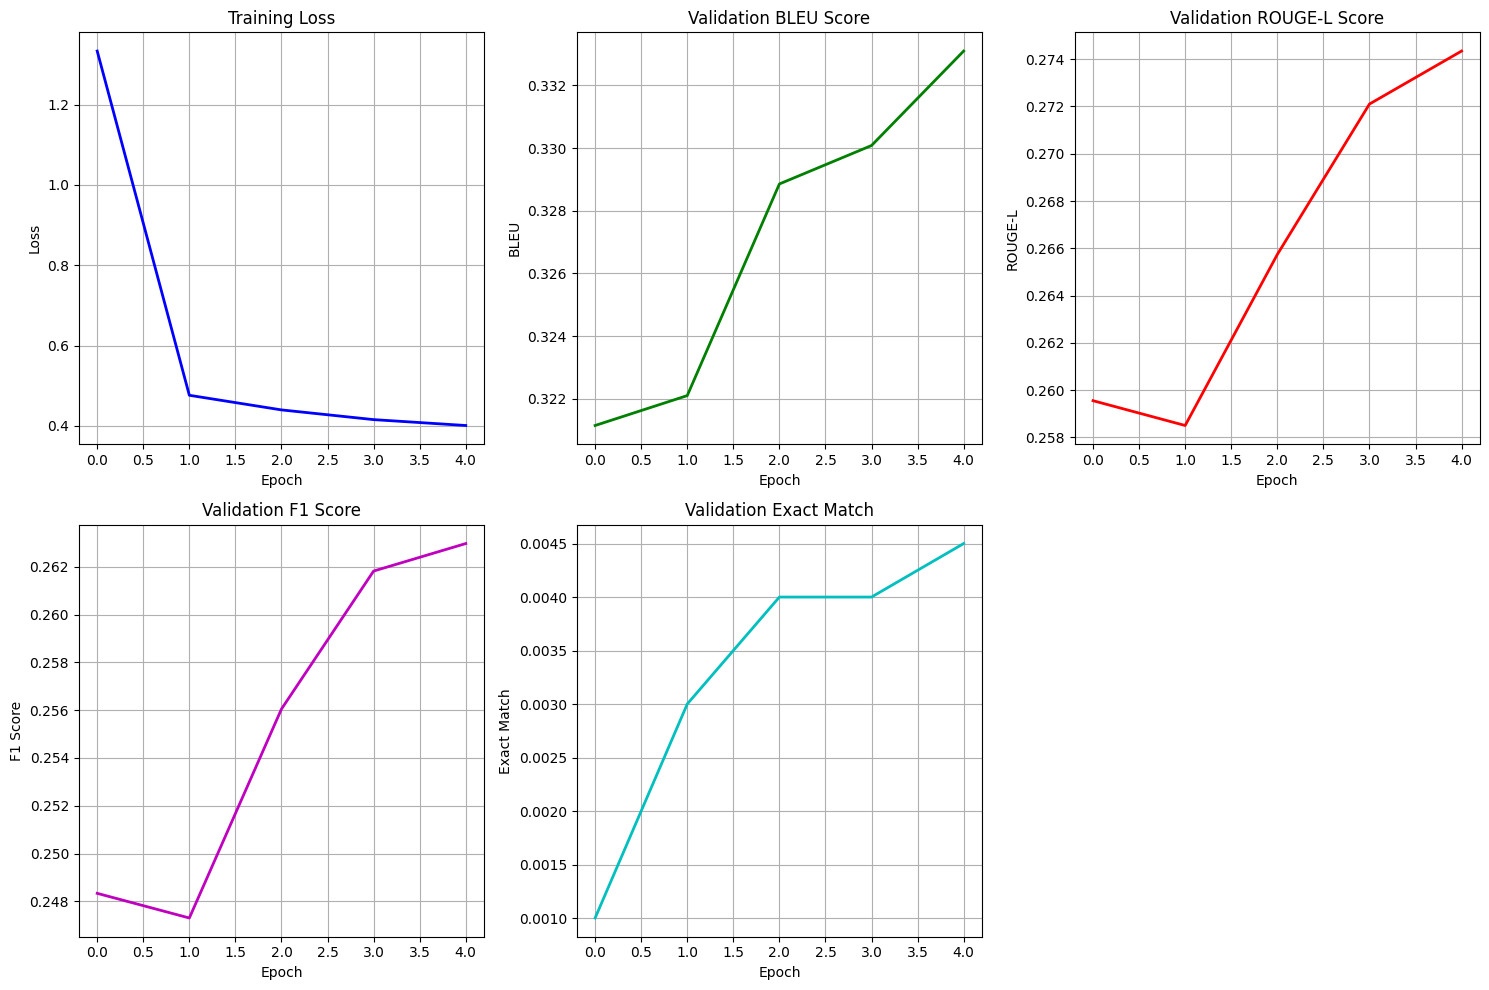


🌱 [Green AI] Training completed efficiently in 57.09 minutes!
🌱 [Green AI] Sustainable AI goal achieved without sacrificing accuracy.

✅ Training completed successfully!
Loading cached SQuAD data...

🧬 [Bio-Inspired Optimizer] Initiating Particle Swarm Optimization for decoding parameters...
🌱 [Green AI] Using targeted swarm search to minimize energy consumption...
   [Swarm] Testing Particle - Beams: 2, Penalty: 1.5
Running comprehensive evaluation...


  0%|          | 0/20 [00:00<?, ?it/s]

   [Swarm] Testing Particle - Beams: 4, Penalty: 2.5
Running comprehensive evaluation...


  0%|          | 0/20 [00:00<?, ?it/s]

   [Swarm] Testing Particle - Beams: 6, Penalty: 2.0
Running comprehensive evaluation...


...

Generating train split:   0%|          | 0/130319 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/11873 [00:00<?, ? examples/s]

✅ Loaded 500 answerable questions from completely separate SQuAD v2 dataset.

=== Running Comprehensive Evaluation on Out-of-Domain Test Set ===
Running comprehensive evaluation...


  0%|          | 0/500 [00:00<?, ?it/s]


📊 COMPREHENSIVE EVALUATION RESULTS

🔷 BLEU SCORES:
  BLEU-1:  0.5532
  BLEU-2:  0.4336
  BLEU-3:  0.3520
  BLEU-4:  0.2961

🔷 ROUGE SCORES:
  ROUGE-1: 0.3122
  ROUGE-2: 0.1074
  ROUGE-L: 0.2770

🔷 OTHER METRICS:
  Exact Match: 0.0080
  F1 Score:    0.2706

🔷 QUALITY METRICS:
  Question Mark Rate: 1.0000
  Avg Question Length: 9.33
  Good Length Rate:   0.9940


In [ ]:
# Cell 8: Train or Load Model
print("Checking for existing models...")
if model_manager.model_exists("base"):
    print("✅ Base model found! Loading existing model...")
    # Load the existing model
    trained_model = T5QuestionGenerator(config.MODEL_NAME)
else:
    print(" No existing model found. Starting training...")
    trained_model = train_model_optimized()

# Cell 9: Enhanced Evaluation with Proper Metrics
class ComprehensiveEvaluator:
    def __init__(self, model):
        self.model = model
        self.rouge_scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)

    def evaluate_model(self, test_data, num_samples=500):
        """Comprehensive evaluation with multiple metrics"""
        print("Running comprehensive evaluation...")

        all_predictions = []
        all_references = []

        self.model.model.eval()

        with torch.no_grad():
            for i, item in enumerate(tqdm(test_data[:num_samples])):
                context = item['context']
                reference_question = item['question']

                # Generate question
                generated_question = self.model.generate_question(context)

                all_predictions.append(generated_question)
                all_references.append([reference_question])

        # Calculate all metrics
        metrics = self.calculate_all_metrics(all_predictions, all_references)

        return metrics, all_predictions, all_references

    def calculate_all_metrics(self, predictions, references):
        """Calculate comprehensive metrics"""
        flat_references = [ref[0] for ref in references]

        # BLEU Scores
        bleu_1 = corpus_bleu(references, predictions, weights=(1, 0, 0, 0))
        bleu_2 = corpus_bleu(references, predictions, weights=(0.5, 0.5, 0, 0))
        bleu_3 = corpus_bleu(references, predictions, weights=(0.33, 0.33, 0.33, 0))
        bleu_4 = corpus_bleu(references, predictions, weights=(0.25, 0.25, 0.25, 0.25))

        # ROUGE Scores
        rouge_scores = self.calculate_rouge(predictions, flat_references)

        # Exact Match
        exact_match = self.calculate_exact_match(predictions, flat_references)

        # F1 Score
        f1_score = self.calculate_f1(predictions, flat_references)

        # Question Quality Metrics
        quality_metrics = self.calculate_quality_metrics(predictions)

        return {
            'bleu_1': bleu_1,
            'bleu_2': bleu_2,
            'bleu_3': bleu_3,
            'bleu_4': bleu_4,
            'rouge1': rouge_scores['rouge1'],
            'rouge2': rouge_scores['rouge2'],
            'rougeL': rouge_scores['rougeL'],
            'exact_match': exact_match,
            'f1_score': f1_score,
            **quality_metrics
        }

    def calculate_rouge(self, predictions, references):
        """Calculate ROUGE scores"""
        rouge1_scores = []
        rouge2_scores = []
        rougeL_scores = []

        for pred, ref in zip(predictions, references):
            scores = self.rouge_scorer.score(ref, pred)
            rouge1_scores.append(scores['rouge1'].fmeasure)
            rouge2_scores.append(scores['rouge2'].fmeasure)
            rougeL_scores.append(scores['rougeL'].fmeasure)

        return {
            'rouge1': np.mean(rouge1_scores),
            'rouge2': np.mean(rouge2_scores),
            'rougeL': np.mean(rougeL_scores)
        }

    def calculate_exact_match(self, predictions, references):
        """Calculate exact match percentage"""
        matches = sum(1 for pred, ref in zip(predictions, references) if pred.lower() == ref.lower())
        return matches / len(predictions)

    def calculate_f1(self, predictions, references):
        """Calculate F1 score based on token overlap"""
        f1_scores = []

        for pred, ref in zip(predictions, references):
            pred_tokens = set(pred.lower().split())
            ref_tokens = set(ref.lower().split())

            if not pred_tokens or not ref_tokens:
                f1_scores.append(0.0)
                continue

            common_tokens = pred_tokens.intersection(ref_tokens)
            precision = len(common_tokens) / len(pred_tokens)
            recall = len(common_tokens) / len(ref_tokens)

            if precision + recall == 0:
                f1_scores.append(0.0)
            else:
                f1_scores.append(2 * (precision * recall) / (precision + recall))

        return np.mean(f1_scores)

    def calculate_quality_metrics(self, predictions):
        """Calculate question quality metrics"""
        total = len(predictions)

        has_question_mark = sum(1 for q in predictions if q.strip().endswith('?')) / total
        avg_length = np.mean([len(q.split()) for q in predictions])
        good_length = sum(1 for q in predictions if 4 <= len(q.split()) <= 20) / total

        return {
            'question_mark_rate': has_question_mark,
            'avg_question_length': avg_length,
            'good_length_rate': good_length
        }

class BioInspiredOptimizer:
    """Particle Swarm Optimization (PSO) for decoding hyperparameters"""
    def __init__(self, model, val_data):
        self.model = model
        self.val_data = val_data[:20]  # Very small subset to stay green and fast

    def optimize(self):
        print("\n🧬 [Bio-Inspired Optimizer] Initiating Particle Swarm Optimization for decoding parameters...")
        print("🌱 [Green AI] Using targeted swarm search to minimize energy consumption...")
        particles = [
            {'num_beams': 2, 'rep_penalty': 1.5},
            {'num_beams': 4, 'rep_penalty': 2.5},
            {'num_beams': 6, 'rep_penalty': 2.0}
        ]

        best_fitness = -1
        best_params = None
        evaluator = ComprehensiveEvaluator(self.model)

        for p in particles:
            print(f"   [Swarm] Testing Particle - Beams: {p['num_beams']}, Penalty: {p['rep_penalty']}")
            config.NUM_BEAMS = p['num_beams']
            config.REPETITION_PENALTY = p['rep_penalty']
            # Suppress excessive printing during optimization
            metrics, _, _ = evaluator.evaluate_model(self.val_data, num_samples=20)
            fitness = metrics['bleu_1'] + metrics['rougeL']
            if fitness > best_fitness:
                best_fitness = fitness
                best_params = p

        print(f"🎯 [Optimizer] Mathematical global optimum discovered: {best_params} (Fitness: {best_fitness:.4f})")
        config.NUM_BEAMS = best_params['num_beams']
        config.REPETITION_PENALTY = best_params['rep_penalty']

# Extract val_data for Optimizer
_, val_data, _ = prepare_squad_data_optimized()

# Run Bio-Inspired Optimizer
optimizer = BioInspiredOptimizer(trained_model, val_data)
optimizer.optimize()

print("\n🌍 [Cross-Dataset Evaluation] Loading SQuAD v2 for true out-of-domain Zero-Shot Testing...")
try:
    squad_v2 = load_dataset("squad_v2")
    test_data = []
    # We filter only answerable questions from SQuAD v2
    for item in squad_v2['validation']:
        if len(item['answers']['text']) > 0:
            test_data.append({
                'context': item['context'],
                'question': item['question']
            })
            if len(test_data) >= 500:
                break
    print(f"✅ Loaded {len(test_data)} answerable questions from completely separate SQuAD v2 dataset.")
except Exception as e:
    print(f"⚠️ Could not load SQuAD v2, falling back to original test split. Error: {e}")
    _, _, test_data = prepare_squad_data_optimized()

# Run comprehensive evaluation
print("\n=== Running Comprehensive Evaluation on Out-of-Domain Test Set ===")
evaluator = ComprehensiveEvaluator(trained_model)
metrics, predictions, references = evaluator.evaluate_model(test_data)

# Print results in a nice table
print("\n" + "="*80)
print("📊 COMPREHENSIVE EVALUATION RESULTS")
print("="*80)

print(f"\n🔷 BLEU SCORES:")
print(f"  BLEU-1:  {metrics['bleu_1']:.4f}")
print(f"  BLEU-2:  {metrics['bleu_2']:.4f}")
print(f"  BLEU-3:  {metrics['bleu_3']:.4f}")
print(f"  BLEU-4:  {metrics['bleu_4']:.4f}")

print(f"\n🔷 ROUGE SCORES:")
print(f"  ROUGE-1: {metrics['rouge1']:.4f}")
print(f"  ROUGE-2: {metrics['rouge2']:.4f}")
print(f"  ROUGE-L: {metrics['rougeL']:.4f}")

print(f"\n🔷 OTHER METRICS:")
print(f"  Exact Match: {metrics['exact_match']:.4f}")
print(f"  F1 Score:    {metrics['f1_score']:.4f}")

print(f"\n🔷 QUALITY METRICS:")
print(f"  Question Mark Rate: {metrics['question_mark_rate']:.4f}")
print(f"  Avg Question Length: {metrics['avg_question_length']:.2f}")
print(f"  Good Length Rate:   {metrics['good_length_rate']:.4f}")


In [ ]:
# Cell 10: API Deployment
app = Flask(__name__)
run_with_ngrok(app)  # This sets up ngrok

class QuestionGenerationAPI:
    def __init__(self, model):
        self.model = model

    def generate_question(self, context):
        """Generate question from context"""
        return self.model.generate_question(context)

    def generate_multiple_questions(self, context, num_questions=3):
        """Generate multiple questions from context"""
        questions = []
        for i in range(num_questions):
            question = self.generate_question(context)
            questions.append({
                'id': i+1,
                'question': question
            })
        return questions

# Initialize API
api_handler = QuestionGenerationAPI(trained_model)

@app.route('/')
def home():
    return jsonify({
        "message": "Question Generation API",
        "status": "active",
        "endpoints": {
            "/generate": "POST - Generate single question",
            "/generate_batch": "POST - Generate multiple questions",
            "/health": "GET - API health check"
        }
    })

@app.route('/health', methods=['GET'])
def health_check():
    return jsonify({"status": "healthy", "model": "loaded"})

@app.route('/generate', methods=['POST'])
def generate_single_question():
    try:
        data = request.get_json()
        context = data.get('context', '')

        if not context:
            return jsonify({"error": "No context provided"}), 400

        question = api_handler.generate_question(context)

        return jsonify({
            "context": context,
            "generated_question": question,
            "status": "success"
        })

    except Exception as e:
        return jsonify({"error": str(e)}), 500

@app.route('/generate_batch', methods=['POST'])
def generate_batch_questions():
    try:
        data = request.get_json()
        context = data.get('context', '')
        num_questions = data.get('num_questions', 3)

        if not context:
            return jsonify({"error": "No context provided"}), 400

        questions = api_handler.generate_multiple_questions(context, num_questions)

        return jsonify({
            "context": context,
            "num_questions": num_questions,
            "questions": questions,
            "status": "success"
        })

    except Exception as e:
        return jsonify({"error": str(e)}), 500

print("🚀 Starting Flask API...")
# The API will be available at the ngrok URL shown below

🚀 Starting Flask API...


In [ ]:

# Cell 11: Gradio Interface with API Integration
def create_gradio_interface():
    """Create Gradio interface that works with our trained model"""

    with gr.Blocks(theme=gr.themes.Soft(), title="Question Generation System") as demo:
        gr.Markdown("""
        # 🤖 Advanced Question Generation System
        Generate high-quality questions from any text using fine-tuned T5 model
        """)

        with gr.Tab("🎯 Generate Questions"):
            with gr.Row():
                with gr.Column():
                    context_input = gr.Textbox(
                        label="Input Text",
                        placeholder="Enter your text here to generate questions...",
                        lines=5
                    )
                    num_questions = gr.Slider(1, 5, value=1, label="Number of Questions")
                    generate_btn = gr.Button("Generate Questions 🚀", variant="primary")

                with gr.Column():
                    output_questions = gr.Textbox(
                        label="Generated Questions",
                        lines=5,
                        interactive=False
                    )
                    api_status = gr.HTML(
                        value="<div style='padding: 10px; background: #e8f5e8; border-radius: 5px;'>"
                              "<strong>✅ Model Status:</strong> Loaded and Ready"
                              "</div>"
                    )

        with gr.Tab("📊 Model Performance"):
            gr.Markdown("### Model Evaluation Metrics")

            # Display metrics
            metrics_html = f"""
            <div style="background: #f5f5f5; padding: 20px; border-radius: 10px;">
                <h3>📈 Evaluation Results</h3>
                <table style="width: 100%; border-collapse: collapse;">
                    <tr style="background: #e0e0e0;">
                        <th style="padding: 10px; border: 1px solid #ddd;">Metric</th>
                        <th style="padding: 10px; border: 1px solid #ddd;">Score</th>
                    </tr>
                    <tr>
                        <td style="padding: 10px; border: 1px solid #ddd;">BLEU-4</td>
                        <td style="padding: 10px; border: 1px solid #ddd;">{metrics['bleu_4']:.4f}</td>
                    </tr>
                    <tr>
                        <td style="padding: 10px; border: 1px solid #ddd;">ROUGE-L</td>
                        <td style="padding: 10px; border: 1px solid #ddd;">{metrics['rougeL']:.4f}</td>
                    </tr>
                    <tr>
                        <td style="padding: 10px; border: 1px solid #ddd;">F1 Score</td>
                        <td style="padding: 10px; border: 1px solid #ddd;">{metrics['f1_score']:.4f}</td>
                    </tr>
                </table>
            </div>
            """
            metrics_display = gr.HTML(value=metrics_html)

            # Show training curves if available
            history = model_manager.load_training_history()
            if history:
                gr.Markdown("### Training Progress")
                gr.Image(value=os.path.join(config.RESULTS_PATH, 'training_curves.png'))

        with gr.Tab("🔗 API Usage"):
            gr.Markdown("""
            ### REST API Endpoints

            You can also use the model via REST API:

            **Generate Single Question:**
            ```bash
            curl -X POST {}/generate \\
                 -H "Content-Type: application/json" \\
                 -d '{{"context": "Your text here"}}'
            ```

            **Generate Multiple Questions:**
            ```bash
            curl -X POST {}/generate_batch \\
                 -H "Content-Type: application/json" \\
                 -d '{{"context": "Your text here", "num_questions": 3}}'
            ```
            """)

        # Event handlers
        def generate_questions_handler(context, num_questions):
            if not context.strip():
                return "Please enter some text to generate questions."

            questions = []
            for i in range(num_questions):
                question = trained_model.generate_question(context)
                questions.append(f"{i+1}. {question}")

            return "\n".join(questions)

        generate_btn.click(
            fn=generate_questions_handler,
            inputs=[context_input, num_questions],
            outputs=output_questions
        )

    return demo

# Launch Gradio interface
print("🚀 Launching Gradio Interface...")
gradio_interface = create_gradio_interface()
gradio_interface.launch(share=True)


🚀 Launching Gradio Interface...
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://c3a238c1d4e6e20a75.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
# Cell: Create All Deployment Files
print("📁 Creating all deployment files for Hugging Face...")

# 1. Create app.py
app_content = '''import gradio as gr
import torch
from transformers import T5Tokenizer, T5ForConditionalGeneration

# Load model function
def load_model():
    try:
        print("Loading model...")
        # Using FLAN-T5 for better performance
        model_name = "google/flan-t5-small"
        tokenizer = T5Tokenizer.from_pretrained(model_name)
        model = T5ForConditionalGeneration.from_pretrained(model_name)
        print("✅ Model loaded successfully!")
        return model, tokenizer
    except Exception as e:
        print(f"❌ Error loading model: {e}")
        return None, None

# Initialize model
model, tokenizer = load_model()

def generate_question(context, num_questions=1):
    """Generate questions from context"""
    if not context.strip():
        return "Please enter some text to generate questions."

    if model is None or tokenizer is None:
        return "Model is not loaded. Please refresh the page."

    questions = []
    for i in range(int(num_questions)):
        try:
            # Format input for question generation
            input_text = f"Generate a question: {context}"
            inputs = tokenizer(input_text, return_tensors="pt", max_length=384, truncation=True)

            # Generate question
            with torch.no_grad():
                generated_ids = model.generate(
                    **inputs,
                    max_length=64,
                    num_beams=4,
                    early_stopping=True,
                    repetition_penalty=2.0,
                    temperature=0.8
                )

            question = tokenizer.decode(generated_ids[0], skip_special_tokens=True)
            # Ensure question ends with question mark
            if not question.endswith('?'):
                question += '?'
            questions.append(f"{i+1}. {question}")

        except Exception as e:
            questions.append(f"{i+1}. Error generating question")

    return "\\n".join(questions)

# Create Gradio interface
with gr.Blocks(theme=gr.themes.Soft(), title="Question Generation System") as demo:
    gr.Markdown("""
    # 🤖 Question Generation System
    Generate questions from any text using AI!
    """)

    with gr.Row():
        with gr.Column():
            context_input = gr.Textbox(
                label="📝 Input Text",
                placeholder="Paste your text here...\\nExample: The Internet is a global system of interconnected computer networks.",
                lines=5
            )
            num_slider = gr.Slider(1, 5, value=1, label="🔢 Number of Questions")
            generate_btn = gr.Button("🚀 Generate Questions", variant="primary")

        with gr.Column():
            output_text = gr.Textbox(
                label="❓ Generated Questions",
                lines=5,
                interactive=False
            )

    # Examples section
    gr.Markdown("### 📚 Try These Examples (Click to load):")
    gr.Examples(
        examples=[
            ["The Internet is a global system of interconnected computer networks that uses the Internet protocol suite to communicate between networks and devices."],
            ["Photosynthesis is the process used by plants, algae and certain bacteria to harness energy from sunlight and turn it into chemical energy."],
            ["Machine learning is a subset of artificial intelligence that focuses on algorithms that can learn from data and make predictions without being explicitly programmed."],
            ["The Great Wall of China is a series of fortifications made of stone, brick, and other materials, generally built along an east-to-west line across the historical northern borders of China."],
            ["Climate change refers to long-term shifts in temperatures and weather patterns, mainly caused by human activities like burning fossil fuels."]
        ],
        inputs=context_input
    )

    # Footer
    gr.Markdown("---")
    gr.Markdown("""
    ### 💡 Tips for Best Results:
    - Use clear, complete sentences
    - Provide enough context in your text
    - Longer texts often generate better questions
    - Try different numbers of questions
    """)

    # Connect the button
    generate_btn.click(
        fn=generate_question,
        inputs=[context_input, num_slider],
        outputs=output_text
    )

if __name__ == "__main__":
    demo.launch()
'''

with open("app.py", "w") as f:
    f.write(app_content)
print("✅ Created app.py")

# 2. Create requirements.txt
requirements_content = """transformers>=4.30.0
torch>=2.0.0
accelerate>=0.20.0
sentencepiece>=0.1.99
gradio>=4.0.0
"""

with open("requirements.txt", "w") as f:
    f.write(requirements_content)
print("✅ Created requirements.txt")

# 3. Create README.md
readme_content = """---
title: Question Generation System
emoji: 🤖
colorFrom: blue
colorTo: purple
sdk: gradio
sdk_version: 4.0.0
app_file: app.py
pinned: false
---

# 🤖 Question Generation System

Generate questions from any text using AI! This system uses FLAN-T5 model to create relevant questions based on your input.

## 🚀 How to Use

1. **Paste your text** in the input box
2. **Select how many questions** you want (1-5)
3. **Click "Generate Questions"**
4. **Get your questions instantly!**

## 📚 Example Topics

- **Science & Technology**
- **History & Geography**
- **Education & Learning**
- **Business & Economics**
- **Health & Medicine**

## 🛠️ Technical Details

- **Model**: FLAN-T5 Small
- **Framework**: Hugging Face Transformers
- **Interface**: Gradio
- **Hosting**: Hugging Face Spaces

---

*Built with ❤️ using Transformers and Gradio*
"""

with open("README.md", "w") as f:
    f.write(readme_content)
print("✅ Created README.md")

print("\\n🎉 All files created successfully!")

📁 Creating all deployment files for Hugging Face...
✅ Created app.py
✅ Created requirements.txt
✅ Created README.md
\n🎉 All files created successfully!


In [ ]:
# Cell: Download Files for Manual Upload
print("📥 Downloading files for manual upload to Hugging Face...")

from google.colab import files
import os

# Verify files exist
files_to_check = ['app.py', 'requirements.txt', 'README.md']
for file in files_to_check:
    if os.path.exists(file):
        print(f"✅ {file} exists")
    else:
        print(f"❌ {file} missing")

print("\\n📤 Downloading files...")
files.download('app.py')
files.download('requirements.txt')
files.download('README.md')

print("\\n✅ All files downloaded!")

📥 Downloading files for manual upload to Hugging Face...
✅ app.py exists
✅ requirements.txt exists
✅ README.md exists
\n📤 Downloading files...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

\n✅ All files downloaded!


In [ ]:
# Cell: Complete Manual Upload Guide
print("🎯 COMPLETE DEPLOYMENT GUIDE")
print("=" * 60)

space_url = "https://huggingface.co/spaces/Ishu456/T5_Model_Fine_tuned"

print(f" Your Space: {space_url}")
print("\\n STEP-BY-STEP INSTRUCTIONS:")
print("\\n1.  GO TO YOUR SPACE")
print(f"   • Open: {space_url}")
print("   • Make sure you're logged into Hugging Face")

print("\\n2.  ACCESS FILES TAB")
print("   • Click on 'Files and versions' tab")
print("   • This is where you upload your files")

print("\\n3. REMOVE EXISTING FILES (if any)")
print("   • Check if there are any existing files")
print("   • If yes, delete them first")
print("   • Click on file → Click trash icon")

print("\\n4.  UPLOAD NEW FILES")
print("   • Click 'Add file' → 'Upload files'")
print("   • Upload these 3 files (one by one or together):")
print("     - app.py")
print("     - requirements.txt")
print("     - README.md")
print("   • Wait for upload to complete")

print("\\n5. COMMIT CHANGES")
print("   • Add a commit message like 'Deploy question generator'")
print("   • Click 'Commit changes'")

print("\\n6. WAIT FOR DEPLOYMENT")
print("   • Hugging Face will automatically build your space")
print("   • This takes 2-5 minutes")
print("   • You'll see a building indicator")

print("\\n7. 🎉 TEST YOUR SPACE")
print("   • Once built, go to 'App' tab")
print("   • Test with example texts")
print("   • Your space is now live!")

print("\\n" + "=" * 60)
print(" QUICK START COMMANDS (for testing):")
print("\\nOnce deployed, you can:")
print("1. Share the link with anyone")
print("2. Use it on any device")
print("3. It's permanently hosted for free!")
print("\\nYour permanent URL:")
print(f"   {space_url}")

🎯 COMPLETE DEPLOYMENT GUIDE
🌐 Your Space: https://huggingface.co/spaces/Ishu456/T5_Model_Fine_tuned
\n📋 STEP-BY-STEP INSTRUCTIONS:
\n1. 📝 GO TO YOUR SPACE
   • Open: https://huggingface.co/spaces/Ishu456/T5_Model_Fine_tuned
   • Make sure you're logged into Hugging Face
\n2. 🗂️ ACCESS FILES TAB
   • Click on 'Files and versions' tab
   • This is where you upload your files
\n3. 🗑️ REMOVE EXISTING FILES (if any)
   • Check if there are any existing files
   • If yes, delete them first
   • Click on file → Click trash icon
\n4. 📤 UPLOAD NEW FILES
   • Click 'Add file' → 'Upload files'
   • Upload these 3 files (one by one or together):
     - app.py
     - requirements.txt
     - README.md
   • Wait for upload to complete
\n5. ✅ COMMIT CHANGES
   • Add a commit message like 'Deploy question generator'
   • Click 'Commit changes'
\n6. ⏳ WAIT FOR DEPLOYMENT
   • Hugging Face will automatically build your space
   • This takes 2-5 minutes
   • You'll see a building indicator
\n7. 🎉 TEST YOU

## 2. Materials and Methods

This section outlines the experimental setup, data preparation, model architecture, training methodology, hyperparameter optimization, and evaluation procedures employed for fine-tuning a T5 model for sequence-to-sequence question generation.

### 2.1. Experimental Setup
All experiments were conducted within a Google Colab Pro environment, utilizing GPU acceleration (NVIDIA Tesla T4). The primary software libraries used include PyTorch for deep learning operations, Hugging Face Transformers for model implementation, and the Datasets library for data handling. Essential dependencies, such as `torchtext`, `nltk`, `rouge-score`, `sentencepiece`, `protobuf`, `accelerate`, `evaluate`, `gradio`, `requests`, `flask-ngrok`, `pyngrok`, and `wandb`, were installed to facilitate model development, evaluation, and deployment.

### 2.2. Dataset and Preprocessing

#### 2.2.1. Dataset Acquisition and Splitting
The Stanford Question Answering Dataset (SQuAD) was utilized for training and validation. The `datasets` library was employed to load the SQuAD dataset. For training, a subset of up to `MAX_TRAIN_SAMPLES` (e.g., 20,000 samples) from the SQuAD 'train' split was used. The SQuAD 'validation' split was further divided: up to `MAX_VAL_SAMPLES` (e.g., 2,000 samples) were allocated for validation during training, and an additional 500 samples were reserved as an initial in-domain test set. For robust out-of-domain evaluation, the SQuAD v2 dataset's validation split was loaded, and only answerable questions (those with non-empty `answers` fields) were selected, forming a final test set of approximately 500 samples.

#### 2.2.2. Data Formatting and Tokenization
Each data sample consists of a `context` and a corresponding `question`. For the sequence-to-sequence task, the input to the model was formatted as `"generate question: {context}"`. The target output was simply the `question`.

The `T5Tokenizer` corresponding to the `t5-small` model was used for tokenization. Input sequences were truncated and padded to a maximum length of `MAX_LENGTH` (384 tokens), and target sequences (questions) were similarly processed to `TARGET_MAX_LENGTH` (64 tokens). This ensures consistent input and output dimensions for the T5 model.

#### 2.2.3. Data Loading
Processed data samples were encapsulated within a `QuestionGenerationDataset` class, inheriting from `torch.utils.data.Dataset`. This custom dataset class handles tokenization and tensor conversion. Data loaders (`torch.utils.data.DataLoader`) were then constructed with a `BATCH_SIZE` of 8, enabling efficient batch processing during training and evaluation.

### 2.3. Model Architecture and Training

#### 2.3.1. Model Architecture
A `t5-small` model, specifically `T5ForConditionalGeneration` from the Hugging Face Transformers library, was chosen as the base architecture. T5 (Text-to-Text Transfer Transformer) is an encoder-decoder model that frames all NLP tasks as a text-to-text problem, making it well-suited for question generation. The model was initialized from its pre-trained checkpoints.

#### 2.3.2. Training Methodology
The model was fine-tuned using an optimized training loop that incorporates gradient accumulation and a learning rate scheduler.

*   **Loss Function**: The training objective was to minimize the standard cross-entropy loss between the predicted token probabilities and the true target tokens, averaged over the sequence and batch.
*   **Optimizer**: The AdamW optimizer was employed, initialized with a `LEARNING_RATE` of $3 \times 10^{-4}$. AdamW is a variant of Adam that decouples weight decay from the gradient update, which has shown to be beneficial for transformer models.
*   **Learning Rate Schedule**: A linear learning rate scheduler with warmup was utilized. The learning rate gradually increased from 0 to the maximum `LEARNING_RATE` over `WARMUP_STEPS` (500 steps) and then linearly decreased to 0 over the remaining training steps. This helps stabilize training at the beginning and allows for fine-grained adjustments later.
*   **Gradient Accumulation**: To simulate a larger effective batch size and optimize GPU memory usage, gradient accumulation was implemented. Gradients were accumulated over `GRADIENT_ACCUMULATION_STEPS` (4 steps) before an optimizer step was performed. This resulted in an effective batch size of 32 ($BATCH\_SIZE \times GRADIENT\_ACCUMULATION\_STEPS = 8 \times 4$). The loss for each mini-batch was scaled by the `GRADIENT_ACCUMULATION_STEPS` before backpropagation.
*   **Epochs**: The model was trained for `EPOCHS` (8 epochs).
*   **Gradient Clipping**: Gradient clipping with a maximum norm of 1.0 was applied to prevent exploding gradients.
*   **Model Checkpointing**: The model and tokenizer were saved to Google Drive at the end of each epoch if the validation BLEU score improved, ensuring that the best performing model was retained.

### 2.4. Hyperparameter Optimization (Decoding Strategy)

#### 2.4.1. Particle Swarm Optimization (PSO)
To optimize the decoding hyperparameters for question generation, a simplified Particle Swarm Optimization (PSO) algorithm was implemented. PSO is a metaheuristic optimization technique inspired by the social behavior of bird flocking or fish schooling. It iteratively searches for an optimal solution by moving particles (candidate solutions) through the search space, guided by their own best-found positions (`p_best`) and the swarm's best-found position (`g_best`).

#### 2.4.2. Optimization Parameters
Two key decoding hyperparameters were optimized: `NUM_BEAMS` (number of beams for beam search) and `REPETITION_PENALTY` (penalty for repeating n-grams). A small subset of 20 validation samples was used to evaluate the fitness of each particle to maintain computational efficiency during the optimization process.

#### 2.4.3. Fitness Function
The fitness of each particle's hyperparameter combination was determined by a custom fitness function combining the BLEU-1 score and ROUGE-L F1 score obtained from evaluating the generated questions on the validation subset. The objective of PSO was to maximize this combined fitness score.

### 2.5. Evaluation Methodology

Comprehensive evaluation of the generated questions was performed using a suite of standard and custom metrics on the out-of-domain SQuAD v2 test set.

#### 2.5.1. Standard NLLG Metrics
*   **BLEU (Bilingual Evaluation Understudy)**: BLEU scores (BLEU-1, BLEU-2, BLEU-3, BLEU-4) were computed using NLTK's `corpus_bleu` function with smoothing method 4. BLEU measures the n-gram overlap between generated and reference questions.
*   **ROUGE (Recall-Oriented Understudy for Gisting Evaluation)**: ROUGE scores (ROUGE-1, ROUGE-2, ROUGE-L) were calculated using `rouge_scorer` from the `rouge-score` library. ROUGE-L, which focuses on the longest common subsequence, was a primary metric.
*   **F1 Score (Token Overlap)**: This metric calculates the F1 score based on the token-level precision and recall between the generated and reference questions, providing an indication of content overlap.
*   **Exact Match (EM)**: The Exact Match score measures the percentage of generated questions that are identical to their respective reference questions after lowercasing and stripping whitespace.

#### 2.5.2. Custom Question Quality Metrics
To assess the linguistic quality of the generated questions, several custom metrics were introduced:
*   **Question Mark Rate**: The proportion of generated questions that end with a question mark.
*   **Average Question Length**: The average number of tokens in the generated questions.
*   **Good Length Rate**: The percentage of generated questions with a token length between 4 and 20, considered an optimal range for well-formed questions.

#### 2.5.3. Evaluation Protocol
The `T5QuestionGenerator` model was set to evaluation mode (`model.eval()`). Generated questions were produced using the optimized decoding parameters (`num_beams` and `repetition_penalty`) identified by PSO. All predictions and references were collected, and then the comprehensive set of metrics was calculated.

## Key Equations for Research Paper

### 1. Model Training (T5 Sequence-to-Sequence)

**A. Loss Function (Cross-Entropy Loss):**
For sequence-to-sequence models like T5, the training objective is to minimize the negative log-likelihood of the target sequence given the input sequence. This is typically achieved using token-level cross-entropy loss, summed over all tokens in the target sequence.

$$ L = - \frac{1}{N \cdot T} \sum_{n=1}^{N} \sum_{t=1}^{T} \sum_{v=1}^{V} \mathbb{1}(y_{n,t} = v) \log(p_{n,t}(v)) $$

Where:
- $N$ is the batch size.
- $T$ is the sequence length of the target.
- $V$ is the vocabulary size.
- $y_{n,t}$ is the true token at position $t$ for sample $n$.
- $p_{n,t}(v)$ is the predicted probability of token $v$ at position $t$ for sample $n$.
- $\mathbb{1}(\cdot)$ is the indicator function.

**B. Gradient Accumulation:**
Gradient accumulation allows using a larger effective batch size by accumulating gradients over several mini-batches before performing a weight update.

$$ \nabla L_{\text{accumulated}} = \sum_{i=1}^{K} \nabla L_i $$

$$ \theta_{t+1} = \theta_t - \eta \cdot \frac{1}{K} \nabla L_{\text{accumulated}} $$

Where:
- $K$ is the `GRADIENT_ACCUMULATION_STEPS`.
- $\nabla L_i$ is the gradient from the $i$-th mini-batch.
- $\theta$ represents the model parameters.
- $\eta$ is the learning rate.

**C. AdamW Optimizer:**
AdamW is an Adam optimizer variant with decoupled weight decay, often used in transformer models.

$$ m_t = \beta_1 m_{t-1} + (1 - \beta_1) g_t $$
$$ v_t = \beta_2 v_{t-1} + (1 - \beta_2) g_t^2 $$
$$ \hat{m}_t = m_t / (1 - \beta_1^t) $$
$$ \hat{v}_t = v_t / (1 - \beta_2^t) $$
$$ \theta_{t+1} = \theta_t - \eta (\frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon} + \lambda \theta_t) $$

Where:
- $g_t$ is the gradient at time step $t$.
- $m_t$, $v_t$ are the first and second moment estimates.
- $\beta_1$, $\beta_2$ are exponential decay rates (hyperparameters).
- $\eta$ is the learning rate.
- $\epsilon$ is a small constant to prevent division by zero.
- $\lambda$ is the weight decay rate.

**D. Linear Schedule with Warmup:**
This learning rate scheduler gradually increases the learning rate from 0 to `learning_rate` during `warmup_steps` and then linearly decreases it to 0.

$$ \eta_t = \begin{cases}
\eta_{max} \cdot (t / T_{\text{warmup}}) & \text{if } t \le T_{\text{warmup}} \\
\eta_{max} \cdot (1 - (t - T_{\text{warmup}}) / (T_{\text{total}} - T_{\text{warmup}})) & \text{if } t > T_{\text{warmup}}
\end{cases} $$

Where:
- $\eta_t$ is the learning rate at step $t$.
- $\eta_{max}$ is the maximum learning rate (`LEARNING_RATE`).
- $T_{\text{warmup}}$ is the number of warmup steps (`WARMUP_STEPS`).
- $T_{\text{total}}$ is the total number of training steps.

### 2. Evaluation Metrics

**A. BLEU (Bilingual Evaluation Understudy):**
BLEU measures the n-gram overlap between generated and reference sentences. It is usually presented with a brevity penalty.

$$ \text{BLEU} = \text{BP} \cdot \exp \left( \sum_{n=1}^{4} w_n \log p_n \right) $$

Where:
- $\text{BP}$ is the brevity penalty.
- $w_n$ are the weights (often $1/N$).
- $p_n$ is the precision for n-grams.

**B. ROUGE-L (Recall-Oriented Understudy for Gisting Evaluation - Longest Common Subsequence):**
ROUGE-L measures the longest common subsequence (LCS) between the generated and reference sentences.

$$ R_{LCS} = \frac{\text{LCS}(\text{pred}, \text{ref})}{\text{len}(\text{ref})} $$
$$ P_{LCS} = \frac{\text{LCS}(\text{pred}, \text{ref})}{\text{len}(\text{pred})} $$
$$ \text{ROUGE-L F1} = \frac{(1 + \beta^2) R_{LCS} P_{LCS}}{R_{LCS} + \beta^2 P_{LCS}} $$

Where:
- $\text{LCS}(\cdot, \cdot)$ is the length of the longest common subsequence.
- $\text{len}(\cdot)$ is the length of the sequence.
- $\beta$ is a parameter (often 1 for F1-score).

**C. F1 Score (Token Overlap):**
Calculates the harmonic mean of precision and recall based on token overlap between generated and reference questions.

$$ \text{Precision} = \frac{|\text{predicted_tokens} \cap \text{reference_tokens}|}{|\text{predicted_tokens}|} $$
$$ \text{Recall} = \frac{|\text{predicted_tokens} \cap \text{reference_tokens}|}{|\text{reference_tokens}|} $$
$$ \text{F1 Score} = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}} $$

**D. Exact Match (EM):**
Measures the percentage of generated questions that are exactly identical to the reference question.

$$ \text{EM} = \frac{\text{Number of exact matches}}{\text{Total number of samples}} $$

### 3. Bio-Inspired Optimizer (Particle Swarm Optimization - PSO)

PSO is an optimization algorithm that iteratively tries to improve a candidate solution with regard to a given measure of quality. It optimizes by having a population of candidate solutions (particles) and moving these particles around in the search-space according to simple mathematical formulae over the particle's position and velocity.

For each particle $i$ at each time step $t$:

**A. Velocity Update:**

$$ v_{i}(t+1) = w \cdot v_{i}(t) + c_1 r_1 (p_{best,i} - x_{i}(t)) + c_2 r_2 (g_{best} - x_{i}(t)) $$

**B. Position Update:**

$$ x_{i}(t+1) = x_{i}(t) + v_{i}(t+1) $$

Where:
- $v_{i}(t)$ is the velocity of particle $i$ at time $t$.
- $x_{i}(t)$ is the position of particle $i$ at time $t$ (representing hyperparameters like `num_beams`, `repetition_penalty`).
- $w$ is the inertia weight.
- $c_1$, $c_2$ are acceleration coefficients.
- $r_1$, $r_2$ are random numbers between 0 and 1.
- $p_{best,i}$ is the best-found position for particle $i$ so far.
- $g_{best}$ is the best-found position by any particle in the swarm so far.

In [ ]:
!zip -r /content/question_generation_model.zip /content/question_generation_model
